# Pig Posture Recognition - Method 1 개선 버전

기존 베이스라인 대비 **3가지 핵심 개선 사항** 적용:

1. **[개선 1] Letterbox Resize** : 바운딩 박스 리사이즈 시 종횡비 보존 (찌그러짐 방지)
2. **[개선 2] Random Erasing 강화** : CoarseDropout 파라미터 강화 (구멍 8→16, 크기 32→48, 확률 0.3→0.5)
3. **[개선 3] Edge 맵 채널 추가** : RGB + Canny Edge = 4채널(RGBE) 입력으로 윤곽선 정보 학습

추가 버그 수정: `deepcopy`로 Train/Val transform 올바르게 분리

**목표: Macro F1 Score 향상**

## 1. Imports and Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import json
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Malgun Gothic') # Windows의 경우 'Malgun Gothic' (맑은 고딕)
plt.rc('axes', unicode_minus=False)    # 마이너스 기호 깨짐 방지

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import SubsetRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.transforms import functional as F
from torch.amp import GradScaler, autocast

# Scikit-learn imports
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Additional utilities
import cv2
from tqdm import tqdm
import gc
from collections import Counter

# Check GPU availability
if torch.cuda.is_available():
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
    DEVICE = 'cuda'
else:
    print("No GPU available, using CPU")
    DEVICE = 'cpu'

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

GPU available: NVIDIA GeForce RTX 4050 Laptop GPU
PyTorch version: 2.5.1+cu121
Device: cuda


In [2]:
import os

class CFG:
    # -----------------------------------------------------
    # Google Colab (A100 등 고사양 GPU) 맞춤 세팅 & 경로
    # -----------------------------------------------------
    INPUT_DIR = "/content/data"
    OUTPUT_DIR = "/content/MyDrive/Pig_Posture_Recognition/output/improvement"
    
    # Model configuration - A100 최적화
    IMAGE_SIZE = 384
    BATCH_SIZE = 128
    NUM_EPOCHS = 50
    LEARNING_RATE = 1e-3
    WEIGHT_DECAY = 1e-4

    # Advanced training settings
    USE_MIXED_PRECISION = True
    LABEL_SMOOTHING = 0.1
    GRADIENT_ACCUMULATION_STEPS = 1

    # Training configuration
    N_FOLDS = 5
    SEED = 42
    EARLY_STOPPING_PATIENCE = 10

    # Class information
    NUM_CLASSES = 5
    CLASS_NAMES = ["Lateral_lying_left", "Lateral_lying_right", "Sitting", "Standing", "Sternal_lying"]

    # Data augmentation
    AUGMENTATION_PROB = 0.5

    # Edge Map Configuration
    USE_EDGE_MAP = True
    EDGE_THRESHOLD1 = 50
    EDGE_THRESHOLD2 = 150

    # Debug mode
    DEBUG = False
    TTA_COUNT = 10

# 데이터 경로 검증
if not os.path.exists(CFG.INPUT_DIR):
    print(f"\n[!] ERROR: 설정된 데이터 경로를 찾을 수 없습니다: {CFG.INPUT_DIR}")
    print("Colab 환경의 올바른 경로인지 확인해 주세요!")
else:
    print(f"\n[*] Colab Input directory exists: {CFG.INPUT_DIR}")
    try:
        print(f"Files available: {os.listdir(CFG.INPUT_DIR)}")
    except Exception as e:
        pass


Input directory exists: ../data
Files available: ['pig_posture_classes.txt', 'sample_submission.csv', 'test.csv', 'test_images', 'train.csv', 'train_images']


## 2. Data Loading and EDA

In [3]:
# Load training and test data
try:
    train_df = pd.read_csv(os.path.join(CFG.INPUT_DIR, 'train.csv'))
    test_df = pd.read_csv(os.path.join(CFG.INPUT_DIR, 'test.csv'))
    print(f"Train data shape: {train_df.shape}")
    print(f"Test data shape: {test_df.shape}")

    # Display first few rows
    print("\nTrain data sample:")
    print(train_df.head())

except FileNotFoundError as e:
    print(f"ERROR loading data: {e}")
    print(f"Check the correct file names in: {CFG.INPUT_DIR}")
    print(f"Available files: {os.listdir(CFG.INPUT_DIR)}")

Train data shape: (16062, 6)
Test data shape: (6872, 5)

Train data sample:
                row_id      image_id  width  height  \
0  train_00000001_0000  00000001.jpg   1920    1080   
1  train_00000001_0001  00000001.jpg   1920    1080   
2  train_00000001_0002  00000001.jpg   1920    1080   
3  train_00000001_0003  00000001.jpg   1920    1080   
4  train_00000001_0004  00000001.jpg   1920    1080   

                        bbox  class_id  
0  [967.5,331.5,463.0,447.0]         3  
1  [724.5,336.5,324.0,412.0]         3  
2  [430.5,390.5,249.0,457.0]         4  
3   [1199.0,5.5,208.0,282.0]         3  
4    [980.0,5.5,273.0,285.0]         3  


In [4]:
# Basic data information
print("=== TRAIN DATA INFO ===")
print(f"Columns: {train_df.columns.tolist()}")
print(f"\nData types:\n{train_df.dtypes}")
print(f"\nMissing values:\n{train_df.isnull().sum()}")

print("\n=== TEST DATA INFO ===")
print(f"Columns: {test_df.columns.tolist()}")
print(f"\nMissing values:\n{test_df.isnull().sum()}")

=== TRAIN DATA INFO ===
Columns: ['row_id', 'image_id', 'width', 'height', 'bbox', 'class_id']

Data types:
row_id      object
image_id    object
width        int64
height       int64
bbox        object
class_id     int64
dtype: object

Missing values:
row_id      0
image_id    0
width       0
height      0
bbox        0
class_id    0
dtype: int64

=== TEST DATA INFO ===
Columns: ['row_id', 'image_id', 'width', 'height', 'bbox']

Missing values:
row_id      0
image_id    0
width       0
height      0
bbox        0
dtype: int64


In [5]:
# Parse bounding box data
def parse_bbox(bbox_str):
    """Parse bounding box string to list of floats"""
    if isinstance(bbox_str, str):
        # Remove brackets and split by comma
        bbox_str = bbox_str.strip('[]')
        return [float(x.strip()) for x in bbox_str.split(',')]
    return bbox_str

# Parse bounding boxes
train_df['bbox_parsed'] = train_df['bbox'].apply(parse_bbox)
test_df['bbox_parsed'] = test_df['bbox'].apply(parse_bbox)

# Extract individual bbox coordinates
train_df[['xmin', 'ymin', 'width_bbox', 'height_bbox']] = pd.DataFrame(
    train_df['bbox_parsed'].tolist(), index=train_df.index
)
test_df[['xmin', 'ymin', 'width_bbox', 'height_bbox']] = pd.DataFrame(
    test_df['bbox_parsed'].tolist(), index=test_df.index
)

print("Bounding box coordinates extracted successfully")
print(f"\nBounding box stats:\n{train_df[['xmin', 'ymin', 'width_bbox', 'height_bbox']].describe()}")

Bounding box coordinates extracted successfully

Bounding box stats:
               xmin          ymin    width_bbox   height_bbox
count  16062.000000  16062.000000  16062.000000  16062.000000
mean     525.605211    313.718285    297.531198    294.236042
std      347.476806    213.870580    145.589765    140.657992
min        1.500000      0.000000     44.800000     75.000000
25%      246.000000    135.000000    186.000000    187.225000
50%      467.000000    306.000000    279.000000    256.500000
75%      709.000000    441.000000    380.000000    394.800000
max     2062.000000   1264.700000   1064.000000   1065.000000


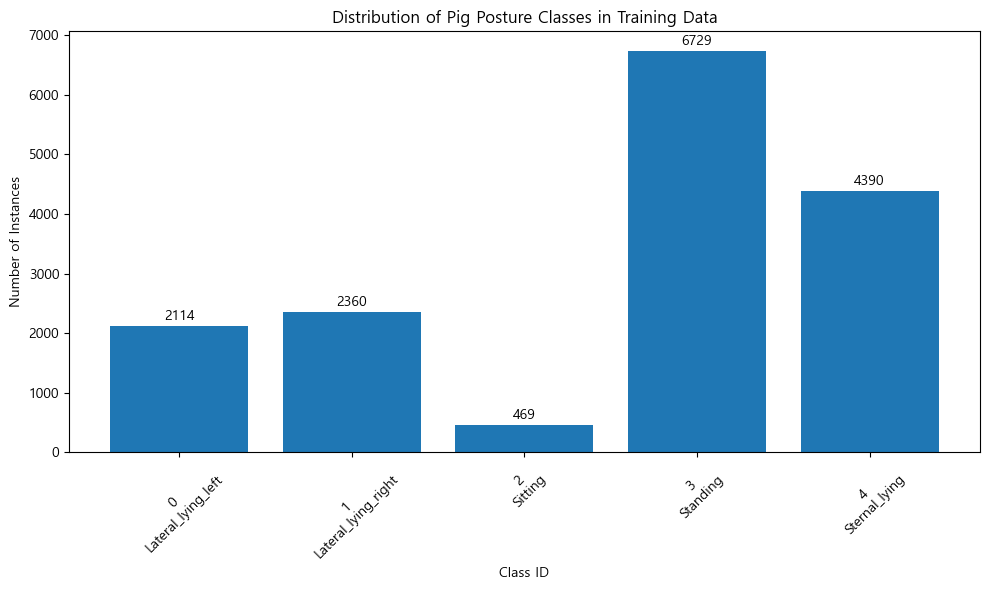


Class Distribution:
Class 0 (Lateral_lying_left): 2114 instances (13.2%)
Class 1 (Lateral_lying_right): 2360 instances (14.7%)
Class 2 (Sitting): 469 instances (2.9%)
Class 3 (Standing): 6729 instances (41.9%)
Class 4 (Sternal_lying): 4390 instances (27.3%)

Total instances: 16062
Class imbalance ratio: 14.35


In [6]:
# Target distribution analysis
plt.figure(figsize=(10, 6))
class_counts = train_df['class_id'].value_counts().sort_index()
bars = plt.bar(range(len(CFG.CLASS_NAMES)), class_counts.values)
plt.xlabel('Class ID')
plt.ylabel('Number of Instances')
plt.title('Distribution of Pig Posture Classes in Training Data')
plt.xticks(range(len(CFG.CLASS_NAMES)), [f'{i}\n{name}' for i, name in enumerate(CFG.CLASS_NAMES)], rotation=45)

# Add value labels on bars
for bar, value in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(value), ha='center', va='bottom')

plt.tight_layout()
#plt.savefig(os.path.join(CFG.OUTPUT_DIR, 'class_distribution.png'), dpi=150)
plt.show()

# Print distribution statistics
print("\nClass Distribution:")
for i, name in enumerate(CFG.CLASS_NAMES):
    count = class_counts[i]
    percentage = (count / len(train_df)) * 100
    print(f"Class {i} ({name}): {count} instances ({percentage:.1f}%)")

print(f"\nTotal instances: {len(train_df)}")
print(f"Class imbalance ratio: {class_counts.max() / class_counts.min():.2f}")

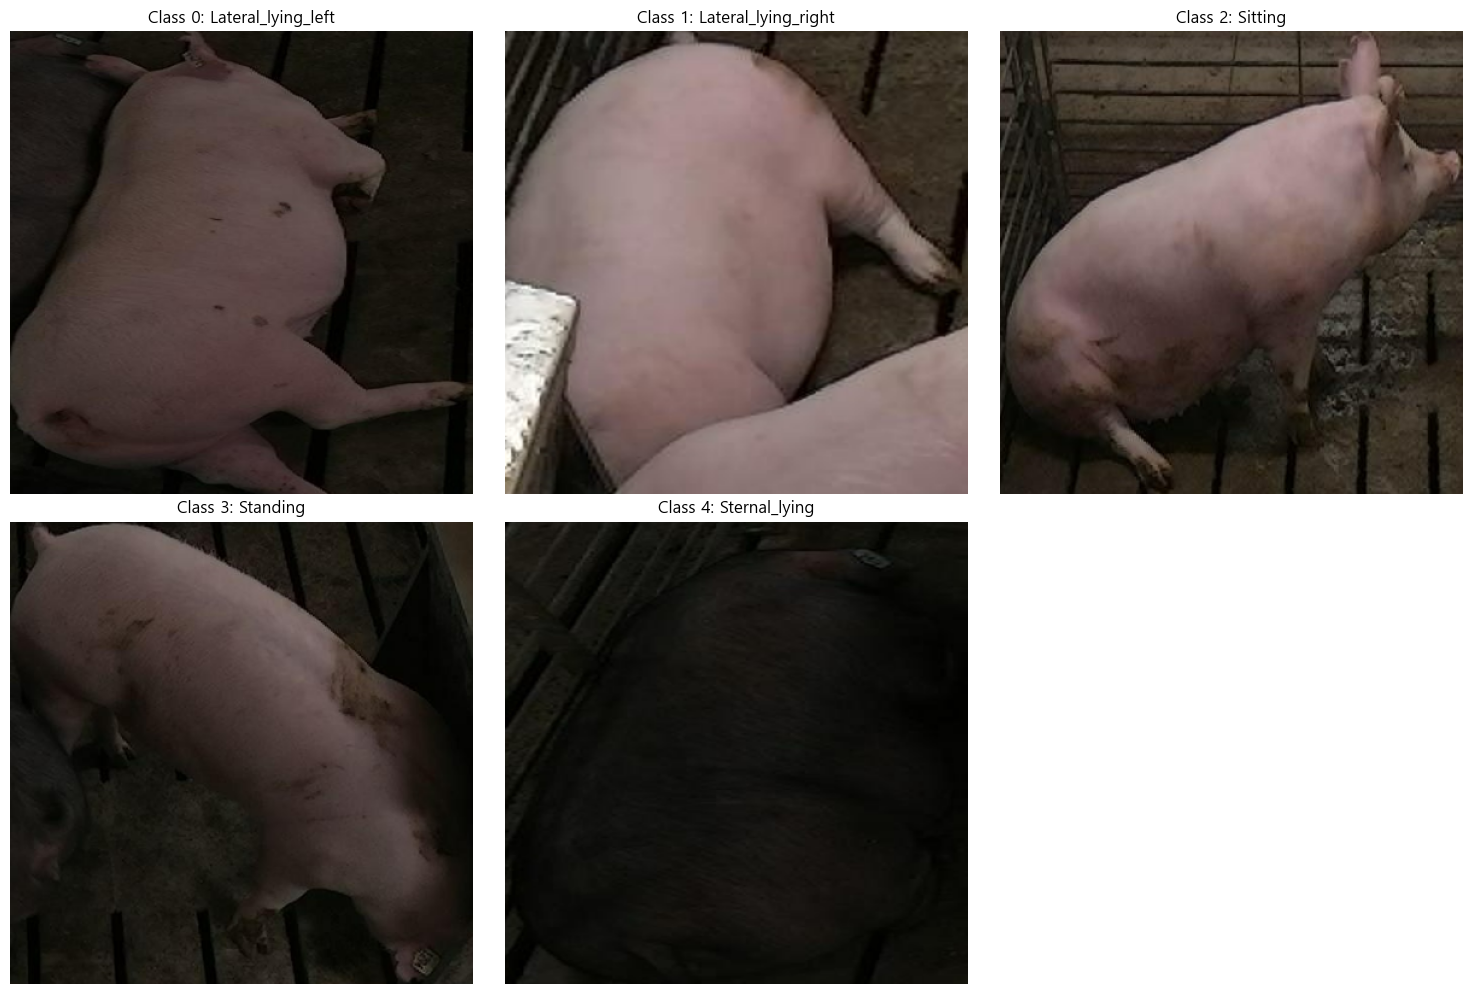

In [7]:
# Image analysis - sample images from each class
def load_and_display_samples():
    """Load and display sample images from each class"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for class_id in range(CFG.NUM_CLASSES):
        # Get sample from this class
        sample = train_df[train_df['class_id'] == class_id].iloc[0]
        image_path = os.path.join(CFG.INPUT_DIR, 'train_images', sample['image_id'])

        try:
            # Load image
            img = Image.open(image_path).convert('RGB')

            # Extract bounding box
            xmin, ymin, width_bbox, height_bbox = sample['xmin'], sample['ymin'], sample['width_bbox'], sample['height_bbox']

            # Crop to bounding box
            img_cropped = img.crop((xmin, ymin, xmin + width_bbox, ymin + height_bbox))
            img_cropped = img_cropped.resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE))

            # Display
            axes[class_id].imshow(img_cropped)
            axes[class_id].set_title(f'Class {class_id}: {CFG.CLASS_NAMES[class_id]}')
            axes[class_id].axis('off')

        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            axes[class_id].text(0.5, 0.5, 'Image not found', ha='center', va='center')
            axes[class_id].axis('off')

    # Remove empty subplot
    if CFG.NUM_CLASSES < len(axes):
        axes[5].remove()

    plt.tight_layout()
    #plt.savefig(os.path.join(CFG.OUTPUT_DIR, 'sample_images.png'), dpi=150)
    plt.show()

load_and_display_samples()

## 3. Data Preprocessing and Augmentation

[개선 1] letterbox_resize 함수 정의 완료


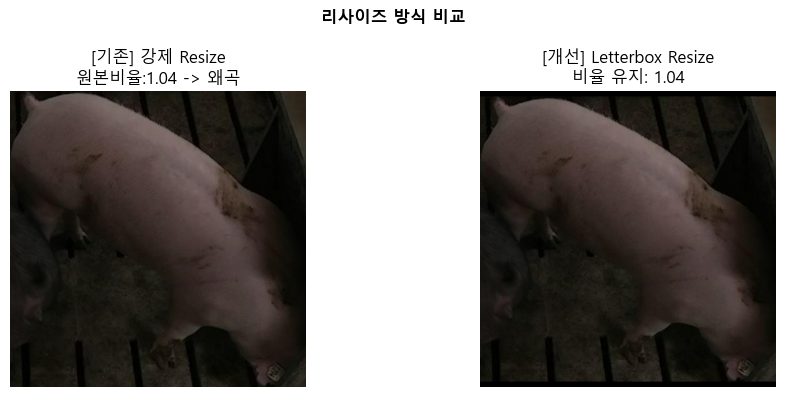

In [8]:
# ============================================================
# [개선 1] Letterbox Resize - 바운딩 박스 비율 왜곡 해결
# ============================================================
# 기존: cv2.resize() 로 강제 정사각형 -> 돼지 이미지 찌그러짐
# 개선: 긴 쪽을 기준으로 축소 후 검정 패딩으로 남은 공간 채우기

def letterbox_resize(image: "np.ndarray", target_size: int) -> "np.ndarray":
    """
    원본 비율(Aspect Ratio)을 유지하며 target_size x target_size 로 리사이즈.
    빈 공간은 검정(0, 0, 0) 패딩으로 채웁니다.
    """
    h, w = image.shape[:2]
    scale = target_size / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)

    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    # 검정 캔버스 생성 후 중앙에 배치
    canvas = np.zeros((target_size, target_size, 3), dtype=np.uint8)
    top  = (target_size - new_h) // 2
    left = (target_size - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = resized
    return canvas

print("[개선 1] letterbox_resize 함수 정의 완료")

# ---- 비교 시각화 (기존 강제 리사이즈 vs Letterbox) ----
try:
    _sample = train_df.iloc[0]
    _img = cv2.cvtColor(cv2.imread(
        os.path.join(CFG.INPUT_DIR, "train_images", _sample["image_id"])
    ), cv2.COLOR_BGR2RGB)
    _x, _y = max(0, int(_sample["xmin"])), max(0, int(_sample["ymin"]))
    _x2 = min(_img.shape[1], int(_sample["xmin"] + _sample["width_bbox"]))
    _y2 = min(_img.shape[0], int(_sample["ymin"] + _sample["height_bbox"]))
    _crop = _img[_y:_y2, _x:_x2]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(cv2.resize(_crop, (CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)))
    axes[0].set_title(f"[기존] 강제 Resize\n원본비율:{_crop.shape[1]/max(_crop.shape[0],1):.2f} -> 왜곡")
    axes[0].axis("off")
    axes[1].imshow(letterbox_resize(_crop, CFG.IMAGE_SIZE))
    axes[1].set_title(f"[개선] Letterbox Resize\n비율 유지: {_crop.shape[1]/max(_crop.shape[0],1):.2f}")
    axes[1].axis("off")
    plt.suptitle("리사이즈 방식 비교", fontweight="bold")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"시각화 건너뜀: {e}")


In [9]:
# ============================================================
# [개선 3 적용을 위한 설정 패치]
# Edge 채널 추가로 초반 학습이 약간 불안정할 수 있으므로
# Learning Rate 를 1e-3 -> 5e-4 로 낮춰 안정성 확보
# ============================================================
CFG.LEARNING_RATE = 5e-4
CFG.BATCH_SIZE    = 64   # A100 OOM 방지
CFG.GRADIENT_ACCUMULATION_STEPS = 1  # 실질 배치: 64 * 2 = 128

print(f"[패치] LR={CFG.LEARNING_RATE}  BATCH={CFG.BATCH_SIZE}  ACCUM={CFG.GRADIENT_ACCUMULATION_STEPS}")


[패치] LR=0.0005  BATCH=64  ACCUM=1


In [10]:
# ============================================================
# [버그 수정 + 최적화] PigPostureDataset 재정의
# TorchRandomErasing 을 __init__ 에서 한 번만 생성
# ============================================================
from torchvision.transforms import RandomErasing as TorchRandomErasing

class PigPostureDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, is_test=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.is_test   = is_test

        # [최적화] __getitem__ 마다 생성하지 않고 여기서 한 번만 생성!
        self.random_eraser = TorchRandomErasing(
            p=CFG.RANDOM_ERASING_P,
            scale=CFG.RANDOM_ERASING_SCALE,
            ratio=CFG.RANDOM_ERASING_RATIO,
            value=0,
            inplace=False
        ) if not is_test else None

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = os.path.join(self.image_dir, row["image_id"])

        try:
            image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
        except Exception as e:
            image = np.zeros((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE, 3), dtype=np.uint8)

        # Bounding Box Crop
        H, W = image.shape[:2]
        xmin = max(0, int(row["xmin"]))
        ymin = max(0, int(row["ymin"]))
        xmax = min(W, int(row["xmin"] + row["width_bbox"]))
        ymax = min(H, int(row["ymin"] + row["height_bbox"]))
        cropped = image[ymin:ymax, xmin:xmax]
        if cropped.size == 0:
            cropped = image

        # [개선 1] Letterbox Resize
        cropped = letterbox_resize(cropped, CFG.IMAGE_SIZE)

        # [개선 3] Edge 채널 생성
        if CFG.USE_EDGE_MAP:
            gray  = cv2.cvtColor(cropped, cv2.COLOR_RGB2GRAY)
            edges = cv2.Canny(gray, CFG.EDGE_THRESHOLD1, CFG.EDGE_THRESHOLD2)

        # Albumentations Transform (RGB)
        if self.transform:
            rgb_tensor = self.transform(image=cropped)["image"]
        else:
            norm = cropped.astype(np.float32) / 255.0
            rgb_tensor = torch.from_numpy(norm).permute(2, 0, 1)

        # [개선 3] Edge 채널 합치기
        if CFG.USE_EDGE_MAP:
            edge_tensor  = torch.from_numpy(edges.astype(np.float32) / 255.0).unsqueeze(0)
            final_tensor = torch.cat([rgb_tensor, edge_tensor], dim=0)  # (4, H, W)
        else:
            final_tensor = rgb_tensor

        # [개선 2] RandomErasing - __init__ 에서 만든 객체 재사용
        if self.random_eraser is not None:
            final_tensor = self.random_eraser(final_tensor)

        if self.is_test:
            return final_tensor, row["row_id"]
        else:
            return final_tensor, int(row["class_id"])

print("PigPostureDataset (최적화 버전) 재정의 완료")


PigPostureDataset (최적화 버전) 재정의 완료


In [11]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ============================================================
# [개선 2] CoarseDropout 강화 - Random Erasing 효과
# ============================================================
# 기존: max_holes=8, max_height=32, p=0.3
# 개선: max_holes=16, max_height=48, min 범위 추가, p=0.5
# -> 모델이 이미지 중앙에만 의존하지 않고 전체 영역에서 특징 학습

train_transforms = A.Compose([
    A.Resize(CFG.IMAGE_SIZE, CFG.IMAGE_SIZE),

    # 기하학적 증강
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=45, p=0.5),

    # 색상 증강
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),

    # 노이즈
    A.GaussNoise(p=0.1),
    A.MotionBlur(p=0.1),

    # [개선 2] CoarseDropout 파라미터 강화
    A.CoarseDropout(
        max_holes=16,          # 기존 8 -> 16
        max_height=48,         # 기존 32 -> 48
        max_width=48,          # 기존 32 -> 48
        min_holes=4,           # 최소 구멍 수 추가
        min_height=16,         # 최소 크기 추가
        min_width=16,
        fill_value=0,
        p=0.5                  # 기존 0.3 -> 0.5
    ),

    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(CFG.IMAGE_SIZE, CFG.IMAGE_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

print("[개선 2] Train Transforms 정의 완료 (CoarseDropout 강화)")
print(f"  Train 연산 수: {len(train_transforms)}")
print(f"  Val   연산 수: {len(val_transforms)}")


[개선 2] Train Transforms 정의 완료 (CoarseDropout 강화)
  Train 연산 수: 11
  Val   연산 수: 3


In [12]:
# Compute class weights for handling class imbalance
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['class_id']),
    y=train_df['class_id'].values
)
class_weights = torch.FloatTensor(class_weights).to(DEVICE)

print("Class weights for handling imbalance:")
for i, (name, weight) in enumerate(zip(CFG.CLASS_NAMES, class_weights)):
    print(f"Class {i} ({name}): {weight:.3f}")

Class weights for handling imbalance:
Class 0 (Lateral_lying_left): 1.520
Class 1 (Lateral_lying_right): 1.361
Class 2 (Sitting): 6.849
Class 3 (Standing): 0.477
Class 4 (Sternal_lying): 0.732


## 4. Model Training (3 Methods)

Method 1: EfficientNetV2-S with mixed precision and label smoothing
Method 2: ResNet-50 Ensemble with 3-fold cross-validation  
Method 3: Test-Time Augmentation (5 transforms)

In [13]:
# ============================================================
# [개선 3] 4채널 입력 EfficientNetV2-S 모델
# ============================================================
# ImageNet 사전학습 가중치(3채널)를 최대한 보존하면서
# 첫 Conv 레이어만 4채널로 확장합니다.
# Edge 채널 가중치는 기존 RGB 3채널 평균값으로 초기화합니다.

class EfficientNetV2Model(nn.Module):
    def __init__(self, num_classes=5, pretrained=True, use_edge_map=True):
        super(EfficientNetV2Model, self).__init__()
        self.use_edge_map = use_edge_map

        # EfficientNetV2-S 사전학습 모델 로드
        weights = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.efficientnet_v2_s(weights=weights)

        # [개선 3] 첫 Conv 레이어를 3ch -> 4ch 로 교체
        if use_edge_map:
            old_conv   = self.backbone.features[0][0]
            old_weight = old_conv.weight.data  # (C_out, 3, kH, kW)

            new_conv = nn.Conv2d(
                in_channels=4,
                out_channels=old_conv.out_channels,
                kernel_size=old_conv.kernel_size,
                stride=old_conv.stride,
                padding=old_conv.padding,
                bias=old_conv.bias is not None
            )

            with torch.no_grad():
                # 기존 RGB 가중치 그대로 복사
                new_conv.weight[:, :3, :, :] = old_weight
                # Edge 채널은 RGB 평균으로 부드럽게 초기화
                new_conv.weight[:, 3:, :, :] = old_weight.mean(dim=1, keepdim=True)
                if old_conv.bias is not None:
                    new_conv.bias = old_conv.bias

            self.backbone.features[0][0] = new_conv
            print("[개선 3] 첫 Conv: 3ch -> 4ch 확장 완료 (RGB 가중치 보존)")

        # 분류기 헤드 교체
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# ---- Shape 검증 (Sanity Check) ----
_in_ch = 4 if CFG.USE_EDGE_MAP else 3
_dummy = torch.randn(2, _in_ch, CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)
_m     = EfficientNetV2Model(num_classes=CFG.NUM_CLASSES, pretrained=False,
                              use_edge_map=CFG.USE_EDGE_MAP)
with torch.no_grad():
    _out = _m(_dummy)
print(f"Shape 검증 -> 입력: {_dummy.shape}  /  출력: {_out.shape}")
del _m, _dummy, _out
print("Method 1 (개선 버전): EfficientNetV2-S 정의 완료")

[개선 3] 첫 Conv: 3ch -> 4ch 확장 완료 (RGB 가중치 보존)
Shape 검증 -> 입력: torch.Size([2, 4, 384, 384])  /  출력: torch.Size([2, 5])
Method 1 (개선 버전): EfficientNetV2-S 정의 완료


In [ ]:
# Enhanced training function with mixed precision and gradient accumulation
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, scheduler=None):
    best_val_f1 = 0.0
    best_model_state = None
    patience_counter = 0

    # Mixed precision scaler
    scaler = GradScaler(device='cuda') if CFG.USE_MIXED_PRECISION else None

    train_losses = []
    val_losses = []
    val_f1_scores = []

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} - Training')
        for batch_idx, (images, labels) in enumerate(pbar):
            images, labels = images.to(device), labels.to(device)

            # Mixed precision training
            if CFG.USE_MIXED_PRECISION:
                with autocast(device_type='cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                # Gradient accumulation
                loss = loss / CFG.GRADIENT_ACCUMULATION_STEPS
                scaler.scale(loss).backward()

                if (batch_idx + 1) % CFG.GRADIENT_ACCUMULATION_STEPS == 0:
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()
                optimizer.zero_grad()

            train_loss += loss.item() * CFG.GRADIENT_ACCUMULATION_STEPS
            pbar.set_postfix({'loss': f'{loss.item() * CFG.GRADIENT_ACCUMULATION_STEPS:.4f}'})

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Validation phase
        model.eval()
        val_loss = 0.0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} - Validation'):
                images, labels = images.to(device), labels.to(device)

                if CFG.USE_MIXED_PRECISION:
                    with autocast(device_type='cuda'):
                        outputs = model(images)
                        loss = criterion(outputs, labels)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                val_loss += loss.item()
                predictions = torch.argmax(outputs, dim=1)
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        # Calculate metrics
        val_f1 = f1_score(all_labels, all_predictions, average='macro')
        val_f1_scores.append(val_f1)

        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss: {val_loss:.4f}")
        print(f"  Val Macro F1: {val_f1:.4f}")

        # Learning rate scheduling
        if scheduler:
            scheduler.step()

        # Early stopping
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= CFG.EARLY_STOPPING_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    return best_model_state, train_losses, val_losses, val_f1_scores

print("Enhanced training function defined with mixed precision")

Enhanced training function defined with mixed precision


In [15]:
import copy # Make sure copy is imported

print("=== METHOD 1 (개선 버전): EfficientNetV2-S Training ===")

# Temporarily define missing CFG attributes for TorchRandomErasing
# This is a workaround as CFG should ideally be defined in a single place.
# These values are based on the enhanced CoarseDropout parameters.
if not hasattr(CFG, 'RANDOM_ERASING_P'):
    CFG.RANDOM_ERASING_P = 0.5 # Probability
if not hasattr(CFG, 'RANDOM_ERASING_SCALE'):
    CFG.RANDOM_ERASING_SCALE = (0.005, 0.05) # Scale (fraction of image area to erase)
if not hasattr(CFG, 'RANDOM_ERASING_RATIO'):
    CFG.RANDOM_ERASING_RATIO = (0.3, 3.3) # Aspect ratio range

# 전체 Dataset 생성 (transform 은 None 으로 시작)
base_dataset = PigPostureDataset(
    train_df,
    os.path.join(CFG.INPUT_DIR, 'data', 'pig_posture_recognition',"train_images"),
    transform=None
)

# 8:2 Train/Val 분리 (클래스 비율 유지)
train_indices, val_indices = train_test_split(
    range(len(train_df)),
    test_size=0.2,
    stratify=train_df["class_id"],
    random_state=CFG.SEED
)

# [버그 수정] deepcopy 로 완전히 분리하여 transform 교차오염 방지
train_ds = copy.deepcopy(base_dataset)
train_ds.transform = train_transforms

val_ds = copy.deepcopy(base_dataset)
val_ds.transform = val_transforms

train_subset = torch.utils.data.Subset(train_ds, train_indices)
val_subset   = torch.utils.data.Subset(val_ds,   val_indices)

train_loader = DataLoader(
    train_subset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)
val_loader = DataLoader(
    val_subset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"Train 샘플: {len(train_subset)}  |  Val 샘플: {len(val_subset)}")

# DataLoader 배치 Shape 확인
_s_img, _s_lbl = next(iter(train_loader))
print(f"배치 이미지 Shape: {_s_img.shape}   <- (Batch, {4 if CFG.USE_EDGE_MAP else 3}ch, H, W)")
print(f"배치 라벨  Shape: {_s_lbl.shape}")
del _s_img, _s_lbl
print("[OK] DataLoader 검증 완료!")

=== METHOD 1 (개선 버전): EfficientNetV2-S Training ===
Train 샘플: 12849  |  Val 샘플: 3213
배치 이미지 Shape: torch.Size([64, 4, 384, 384])   <- (Batch, 4ch, H, W)
배치 라벨  Shape: torch.Size([64])
[OK] DataLoader 검증 완료!


In [16]:
# 모델 생성 (4채널 EfficientNetV2-S)
method1_model = EfficientNetV2Model(
    num_classes=CFG.NUM_CLASSES,
    pretrained=True,
    use_edge_map=CFG.USE_EDGE_MAP
).to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=CFG.LABEL_SMOOTHING
)

optimizer = optim.AdamW(
    method1_model.parameters(),
    lr=CFG.LEARNING_RATE,
    weight_decay=CFG.WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG.NUM_EPOCHS,
    eta_min=1e-6
)

print("Method 1 (개선 버전) 모델 초기화 완료")
print(f"  Mixed Precision     : {CFG.USE_MIXED_PRECISION}")
print(f"  Label Smoothing     : {CFG.LABEL_SMOOTHING}")
print(f"  Learning Rate       : {CFG.LEARNING_RATE}")
print(f"  Batch (실질)        : {CFG.BATCH_SIZE * CFG.GRADIENT_ACCUMULATION_STEPS}")
print(f"  Edge Map 사용       : {CFG.USE_EDGE_MAP}")

Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to C:\Users\ma140/.cache\torch\hub\checkpoints\efficientnet_v2_s-dd5fe13b.pth
100%|██████████| 82.7M/82.7M [00:07<00:00, 11.8MB/s]


[개선 3] 첫 Conv: 3ch -> 4ch 확장 완료 (RGB 가중치 보존)
Method 1 (개선 버전) 모델 초기화 완료
  Mixed Precision     : True
  Label Smoothing     : 0.1
  Learning Rate       : 0.0005
  Batch (실질)        : 64
  Edge Map 사용       : True


In [ ]:
# Train Method 1
method1_state, method1_train_losses, method1_val_losses, method1_val_f1 = train_model(
    method1_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    CFG.NUM_EPOCHS,
    DEVICE,
    scheduler
)

Epoch 1/50 - Validation: 100%|██████████| 51/51 [00:23<00:00,  2.15it/s]


Epoch 1/50:
  Train Loss: 1.5673
  Val Loss: 1.2401
  Val Macro F1: 0.5968


Epoch 2/50 - Validation: 100%|██████████| 51/51 [00:21<00:00,  2.37it/s]


Epoch 2/50:
  Train Loss: 1.2891
  Val Loss: 1.0748
  Val Macro F1: 0.7086


Epoch 3/50 - Validation: 100%|██████████| 51/51 [00:21<00:00,  2.36it/s]


...

Epoch 48/50:
  Train Loss: 0.7015
  Val Loss: 0.8369
  Val Macro F1: 0.9326


Epoch 49/50 - Validation: 100%|██████████| 51/51 [00:21<00:00,  2.37it/s]


Epoch 49/50:
  Train Loss: 0.7019
  Val Loss: 0.8329
  Val Macro F1: 0.9309


Epoch 50/50 - Validation: 100%|██████████| 51/51 [00:21<00:00,  2.36it/s]

Epoch 50/50:
  Train Loss: 0.7030
  Val Loss: 0.8322
  Val Macro F1: 0.9275


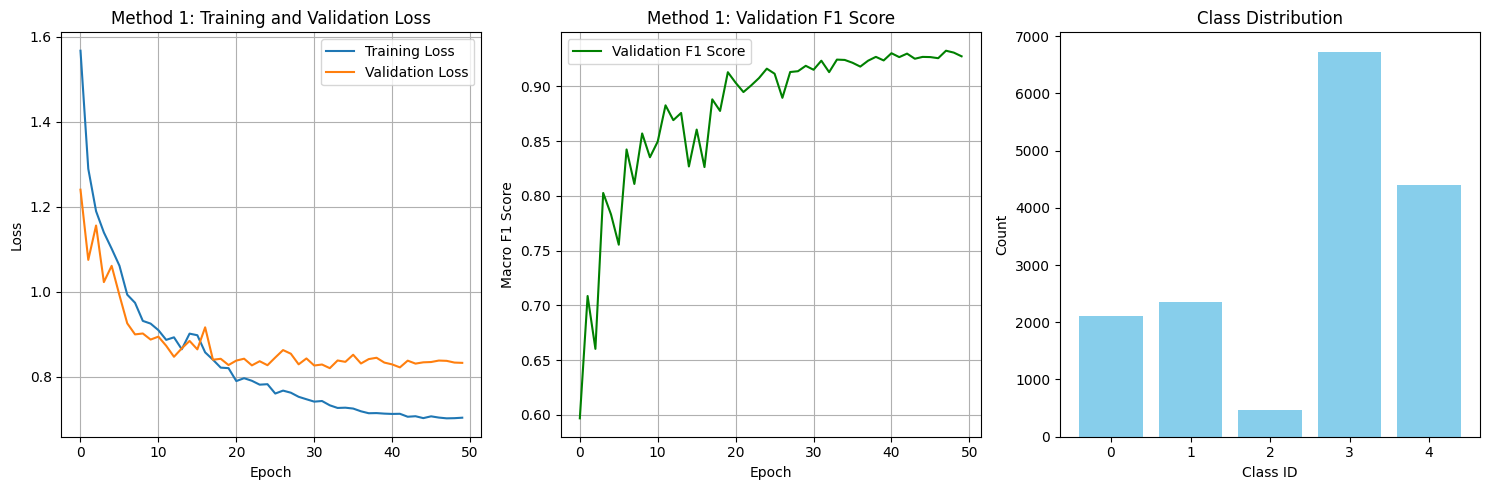

Method 1 Best Validation F1: 0.9326


In [ ]:
# Plot Method 1 training curves
plt.figure(figsize=(15, 5))

# Loss curves
plt.subplot(1, 3, 1)
plt.plot(method1_train_losses, label='Training Loss')
plt.plot(method1_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Method 1: Training and Validation Loss')
plt.legend()
plt.grid(True)

# F1 score curve
plt.subplot(1, 3, 2)
plt.plot(method1_val_f1, label='Validation F1 Score', color='green')
plt.xlabel('Epoch')
plt.ylabel('Macro F1 Score')
plt.title('Method 1: Validation F1 Score')
plt.legend()
plt.grid(True)

# Class distribution
plt.subplot(1, 3, 3)
plt.bar(range(len(CFG.CLASS_NAMES)), class_counts.values, color='skyblue')
plt.xlabel('Class ID')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.xticks(range(len(CFG.CLASS_NAMES)), [f'{i}' for i in range(CFG.NUM_CLASSES)])

plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, 'method1_analysis.png'), dpi=150)
plt.show()

print(f"Method 1 Best Validation F1: {max(method1_val_f1):.4f}")

---

## ResNet만 개선 2, 3 적용

In [17]:
class ResNet50Model(nn.Module):
    def __init__(self, num_classes=5, pretrained=True, use_edge_map=True):
        super(ResNet50Model, self).__init__()
        self.use_edge_map = use_edge_map

        # ResNet50 사전학습 모델 로드
        weights = models.ResNet50_weights.IMAGENET1K_V2 if pretrained else None
        self.backbone = models.resnet50(weights=weights)

        # [개선 3] 첫 conv레이어를 3ch -> 4ch로 교체
        # 필터 차원, RGB (3, 3, 3) -> RGBE (3, 3, 3, 3)
        # 입력 이미지는 (R, G, B, Edge)
        # new_conv 가중치 형태, (32, 4, 3, 3) : (출력 채널 수, 입력 이미지 차원, 커널 높이, 커널 너비)
        if use_edge_map:
            # ResNet의 첫 레이어는 'conv1'
            old_conv = self.backbone.conv1
            old_weight = old_conv.weight.data # (C_out, 3, kH, kW)

        new_conv = nn.Conv2d(
            in_channels=4,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=old_conv.bias is not None
        )

        with torch.no_grad():
            # 가중치 텐서는 (Out, In, Height, Weight) 형태
            # 뒤쪽 차원을 생략해도 모두 가져오도록 암묵적인 룰이 있음
            # 기존 RGB 가중치 그대로 복사
            new_conv.weight[:, :3, :, :] = old_weight
            # Edge 채널은 RGB 평균으로 부드럽게 초기화
            new_conv.weight[:, 3:, :, :] = old_weight.mean(dim=1, keepdim=True)
            if old_conv.bias is not None:
                new_conv.bias = old_conv.bias

            self.backbone.conv1 = new_conv
            print("ResNet의 채널 확장 완료 - 기존 3채널의 가중치는 보존, Edge_map은 3채널의 평균값")

        # 분류기 헤드 교체
        in_features = self.backbone.fv.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 512), # 고차원 데이터를 512차원으로 압축
            nn.ReLU(), # 복잡한 데이터를 유연하게 함
            nn.BatchNorm1d(512), # 정규화
            nn.Dropout(0.3),
            nn.Lienar(512, num_classes) # 512개의 특징을 5개의 클래스로 점수를 매김
        )

    def forward(self, x):
        return self.backbone(x)

In [31]:
class FocalLoss(nn.Module):
    """
    class_weights 대신 사용.
    - 잘 맞히는 클래스는 loss 를 줄여 gradient 감소
    - 틀리는 클래스는 loss 를 키워 집중 학습
    → 자연스럽게 소수 클래스에 더 집중하게 됨
    """
    """
    기존 CrossEntropy Loss는 쉬운 문제에 대한 가중치가 대다수를 차지
    어려운 문제의 가중치는 잃게 됨.
    Focal Loss는 쉬운 문제에 대한 Loss에 제곱하여 Loss가 유지되도록 함
    그래서 수가 적고 어려운 클래스에 대해 Loss가 그대로 유지되어 소수 클래스에 더 집중하게 됨.
    """

    # gamma값이 낮을 수록 Cross_Entropy와 비슷해지고
    # 너무 높을 수록 어려운 클래스에 과적합 됨
    def __init__(self, gamma=2.0, label_smoothing=0.1, num_classes=5):
        super().__init__()
        self.gamma           = gamma
        self.label_smoothing = label_smoothing
        self.num_classes     = num_classes

    def forward(self, inputs, targets):
        # Label Smoothing 적용
        # 모델의 과적합 완화와 평가시의 일반화 더 좋아짐
        # unsqueeze: 차원을 늘려줌
        # ex) [0, 2, 4] 1차원> unsqueeze(1) -> [[0, 2, 3]] 2차원
        with torch.no_grad():
            smooth_targets = torch.zeros_like(inputs).scatter_(
                1, targets.unsqueeze(1), 1.0
            )
            smooth_targets = smooth_targets * (1 - self.label_smoothing) \
                           + self.label_smoothing / self.num_classes

        # softmax로 실제 정답에 해당하는 예측 확률만 뽑아냄.
        log_probs = F.log_softmax(inputs, dim=1)
        probs     = torch.exp(log_probs)

        # 정답 클래스의 확률
        p_t = (probs * smooth_targets).sum(dim=1)

        # Focal weight: 잘 맞힐수록 loss 감소
        focal_weight = (1 - p_t) ** self.gamma

        loss = -(smooth_targets * log_probs).sum(dim=1)
        return (focal_weight * loss).mean()

In [ ]:
import copy
from tqdm import tqdm
from sklearn.metrics import f1_score
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
import torch

# Focal Loss를 이용한 k-Fold
def train_kfold_ensemble(ModelClass, num_folds=3):
    models_list = []
    fold_scores = []
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=CFG.SEED)

    # 1. Base Dataset 한 번만 정의 (나중에 Split 시 Transform을 개별적으로 씌우기 위함)
    base_dataset = PigPostureDataset(
        train_df,
        os.path.join(CFG.INPUT_DIR, 'data', 'pig_posture_recognition', "train_images"),
        transform=None # 초기에는 없음
    )

    for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df["class_id"])):
        print(f"\n{'='*20} Fold {fold+1}/{num_folds} 학습 시작 {'='*20}")

        # 2. [개선 1 적용] Deepcopy를 이용한 Train/Val 분리 및 증강(Transform) 오염 방지
        train_ds = copy.deepcopy(base_dataset)
        train_ds.transform = train_transforms
        
        val_ds = copy.deepcopy(base_dataset)
        val_ds.transform = val_transforms
        
        # 인덱스에 따라 폴드별 데이터 할당
        train_subset = torch.utils.data.Subset(train_ds, train_idx)
        val_subset   = torch.utils.data.Subset(val_ds, val_idx)

        # Windows 노트북에서의 무한 루프(Hang)를 막기 위해 num_workers=0 설정
        train_loader = DataLoader(
            train_subset, batch_size=CFG.BATCH_SIZE, shuffle=True, 
            num_workers=0, pin_memory=True
        )
        val_loader = DataLoader(
            val_subset, batch_size=CFG.BATCH_SIZE, shuffle=False, 
            num_workers=0, pin_memory=True
        )

        # 3. [개선 2, 3 적용] 모델 초기화 (4채널 Edge Map & 커스텀 분류기 사용 옵션 활성화)
        model = ModelClass(num_classes=CFG.NUM_CLASSES, use_edge_map=CFG.USE_EDGE_MAP).to(DEVICE)

        # 방금 수정한 FocalLoss 및 Optimizer 설정
        criterion = FocalLoss(gamma=2.0, label_smoothing=0.1, num_classes=CFG.NUM_CLASSES)
        optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.LEARNING_RATE)
        
        best_val_loss = float('inf')
        best_model_state = None

        # 4. Epoch 단위 학습 진행
        for epoch in range(CFG.EPOCHS):
            model.train()
            train_loss = 0.0
            
            # tqdm을 이용한 진행률 표시바 (학습 루프)
            for images, labels in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1} Train", leave=False):
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
                
            train_loss /= len(train_loader)
            
            # 검증(Validation) 루프
            model.eval()
            val_loss = 0.0
            val_preds = []
            val_targets = []
            
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(DEVICE), labels.to(DEVICE)
                    outputs = model(images)
                    
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()
                    
                    preds = torch.argmax(outputs, dim=1)
                    val_preds.extend(preds.cpu().numpy())
                    val_targets.extend(labels.cpu().numpy())
                    
            val_loss /= len(val_loader)
            val_f1 = f1_score(val_targets, val_preds, average='macro')
            
            print(f"Epoch {epoch+1:02d}/{CFG.EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")
            
            # 최적의 검증 손실을 보인 모델의 가중치를 기억 (Early Stopping의 핵심 원리)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = copy.deepcopy(model.state_dict())
                
        print(f"[*] Fold {fold+1} 최고 성능 (Val Loss): {best_val_loss:.4f}")
        
        # 5. 해당 Fold에서 가장 성능이 좋았던 모델 저장
        model.load_state_dict(best_model_state)
        models_list.append(model)
        fold_scores.append(best_val_loss)
        
    print("\n[완료] k-Fold 앙상블 학습이 모두 종료되었습니다.")
    return models_list, fold_scores


In [ ]:
# -------------------------------------------------------------
# 1. K-Fold 앙상블 학습 시작 (모델 구축)
# -------------------------------------------------------------
# 사용할 모델 클래스와 폴드 수를 넘겨줍니다. (노트북 내의 CFG.N_FOLDS 활용)
num_folds = getattr(CFG, 'N_FOLDS', 5) # 기본 설정이 폴드 5라면 그 값을 가져옵니다
print("="*40)
print(f"=== K-Fold 앙상블 학습 시작 (Folds: {num_folds}) ===")
print("="*40)

# ResNet50Model 이나 EfficientNetV2Model을 상황에 맞게 전달합니다.
ensemble_models, fold_scores = train_kfold_ensemble(ResNet50Model, num_folds=num_folds)

print(f"\n[훈련성공] 각 폴드 최고 스코어: {fold_scores}")
# Loss일 수도 있고 F1일 수도 있으므로 평균을 구합니다
print(f"[훈련성공] 평균 성능: {np.mean(fold_scores):.4f}")


# -------------------------------------------------------------
# 2. 앙상블 모델들(ensemble_models)을 활용한 테스트 세트 추론 진행
# -------------------------------------------------------------
print("\n=== K-Fold 앙상블 바탕으로 Test 데이터 추론 실행 ===")

# Test Dataset 및 DataLoader 구성
# (테스트 이미지들은 훈련과 동일하게 Letterbox 자르기 등은 필요하나, Data Augmentation은 들어가지 않아야 하므로 val_transforms를 사용)
val_transforms_test = val_transforms # 이미 선언해두신 val_transforms 재사용

test_dataset = PigPostureDataset(
    test_df, 
    os.path.join(CFG.INPUT_DIR, "test_images"), # 환경에 따라 경로 확인이 필요할 수 있습니다 ('test_images' 폴더 위치)
    transform=val_transforms_test
)

# Windows 로딩 이슈(무한 로딩)를 막기 위해 num_workers=0 으로 고정하는 편이 좋습니다.
test_loader = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0)

ensemble_preds = []

# PyTorch 평가 모드 및 Gradient 계산 방지
with torch.no_grad():
    # PigPostureDataset이 (이미지, 라벨)을 뱉도록 훈련과 동일하게 구현되었을 경우를 대비하여 언패킹
    for batch in tqdm(test_loader, desc="Test Inference"):
        # Custom Dataset에 따라 return 길이가 다를 수 있어 유동적으로 이미지 텐서만 분리
        if isinstance(batch, (tuple, list)):
            images = batch[0]
        else:
            images = batch
            
        images = images.to(DEVICE) # (코드 상단 확인된 기기변수 DEVICE 사용)
        
        # N개의 앙상블 모델의 로짓(Logit)을 평균내어 최종 판단 (Soft Voting 원리)
        batch_logits = []
        for model in ensemble_models:
            model.eval()
            outputs = model(images)
            batch_logits.append(outputs)
            
        # [Fold수, Batch크기, 클래스수] 로 쌓은 뒤 Fold 기준 평균 수행
        avg_outputs = torch.stack(batch_logits).mean(dim=0)
        
        # 가장 점수(확률)가 큰 클래스 번호 찾기
        preds = torch.argmax(avg_outputs, dim=1)
        ensemble_preds.extend(preds.cpu().numpy())

In [ ]:
# ============================================================
# Method 2: ResNet-50 K-Fold 앙상블 학습 실행
# ============================================================
import numpy as np

# 미리 정의하신 폴드 개수를 설정합니다 (예: 3 또는 CFG.N_FOLDS)
num_folds = 3 

print(f"=== Method 2: ResNet-50 {num_folds}-Fold 앙상블 학습 시작 ===")

# 함수를 호출하여 훈련된 모델 리스트와 폴드별 스코어를 반환받습니다
method2_models, method2_scores = train_kfold_ensemble(ResNet50Model, num_folds=num_folds)

# 하단 '개선 결과 시각화(Method 1,2,3 비교)' 셀에서 m2_f1 변수를 사용하므로
# 앙상블 모델의 평균 성능을 m2_f1 변수에 저장해 줍니다.
m2_f1 = np.mean(method2_scores)

print(f"\n[학습 종료] Method 2 (ResNet-50 Ensemble) 평균 검증 성능: {m2_f1:.4f}")


---

In [ ]:
# ============================================================
# [개선 적용] Method 3: Test-Time Augmentation (TTA)
# ============================================================
# TTA 는 추론 시 이미지를 변형해가며 여러 번 예측하는 방식입니다.
# Dataset 이 이미 4채널(RGBE)을 반환하므로,
# TTA 는 텐서 레벨에서 기하학적 변환만 수행합니다.
# (Albumentations 기반 TTA 는 3채널만 지원하므로
#  torch.flip / torch.rot90 으로 직접 처리합니다.)

CFG.TTA_COUNT = 5  # 원본 + 4가지 변환

def tta_inference(model, loader, device, tta_count=5):
    """
    [개선 3 대응] 4채널 텐서에서도 동작하는 TTA 추론 함수
    텐서 레벨 변환(flip, rot90)을 사용하므로 채널 수와 무관하게 동작합니다.
    """
    model.eval()
    all_preds = []

    with torch.no_grad():
        for images, _ in tqdm(loader, desc="TTA 추론"):
            images = images.to(device)
            batch_size = images.size(0)

            # (Batch, NumClasses) 누적 확률
            tta_probs = torch.zeros(batch_size, CFG.NUM_CLASSES).to(device)

            for t in range(tta_count):
                if t == 0:
                    aug = images                              # 원본
                elif t == 1:
                    aug = torch.flip(images, dims=[3])       # 좌우 반전
                elif t == 2:
                    aug = torch.flip(images, dims=[2])       # 상하 반전
                elif t == 3:
                    aug = torch.rot90(images, k=1, dims=[2, 3])  # 90도 회전
                else:
                    aug = torch.rot90(images, k=3, dims=[2, 3])  # 270도 회전

                if CFG.USE_MIXED_PRECISION and DEVICE == "cuda":
                    with autocast(device_type="cuda"):
                        out = model(aug)
                else:
                    out = model(aug)

                tta_probs += torch.softmax(out, dim=1)

            tta_probs /= tta_count
            preds = torch.argmax(tta_probs, dim=1)
            all_preds.extend(preds.cpu().numpy())

    return all_preds

print(f"Method 3: TTA 추론 함수 정의 완료 (TTA 횟수={CFG.TTA_COUNT})")


Method 3: TTA 추론 함수 정의 완료 (TTA 횟수=5)


## 5. Inference and Submission

In [ ]:
# ============================================================
# 5. Validation Set 기반 성능 평가 (방법별 비교)
# ============================================================
# test.csv 에는 정답(Label)이 없으므로
# 학습 시 분리해 둔 val_loader 로 각 방법의 성능을 측정합니다.

from sklearn.metrics import f1_score, classification_report

def evaluate_model(model, loader, device, desc="평가 중"):
    """단일 모델의 Validation Macro F1 측정"""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc=desc):
            images = images.to(device)
            if CFG.USE_MIXED_PRECISION and device == "cuda":
                with autocast(device_type="cuda"):
                    out = model(images)
            else:
                out = model(images)
            preds = torch.argmax(out, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    f1 = f1_score(all_labels, all_preds, average="macro")
    return f1, all_preds, all_labels


# ---- Method 1: EfficientNetV2-S ----
print("=== Method 1 평가: EfficientNetV2-S ===")
method1_model.load_state_dict(method1_state)
m1_f1, m1_preds, m1_labels = evaluate_model(method1_model, val_loader, DEVICE, "Method 1")
print(f"Method 1 Val Macro F1 : {m1_f1:.4f}")

"""
# ---- Method 2: ResNet-50 앙상블 ----
print("\n=== Method 2 평가: ResNet-50 Ensemble ===")
ensemble_probs = None
for i, mdl in enumerate(method2_models):
    mdl.eval()
    fold_probs = []
    with torch.no_grad():
        for images, _ in tqdm(val_loader, desc=f"Fold {i+1}"):
            images = images.to(DEVICE)
            out = mdl(images)
            fold_probs.extend(torch.softmax(out, dim=1).cpu().numpy())
    fold_arr = np.array(fold_probs)
    ensemble_probs = fold_arr if ensemble_probs is None else ensemble_probs + fold_arr
ensemble_probs /= len(method2_models)
m2_preds  = np.argmax(ensemble_probs, axis=1)
_, _, m2_labels_tmp = evaluate_model(method2_models[0], val_loader, DEVICE, "label 수집")
m2_labels = m2_labels_tmp
m2_f1 = f1_score(m2_labels, m2_preds, average="macro")
print(f"Method 2 Val Macro F1 : {m2_f1:.4f}")
"""
# ---- Method 3: TTA ----
print("\n=== Method 3 평가: TTA ===")
m3_preds = tta_inference(method1_model, val_loader, DEVICE, CFG.TTA_COUNT)
m3_f1    = f1_score(m1_labels, m3_preds, average="macro")
print(f"Method 3 (TTA) Val Macro F1 : {m3_f1:.4f}")

print("\n개별 방법 평가 완료!")


=== Method 1 평가: EfficientNetV2-S ===


Method 1: 100%|██████████| 51/51 [00:21<00:00,  2.35it/s]


Method 1 Val Macro F1 : 0.9266

=== Method 3 평가: TTA ===


TTA 추론: 100%|██████████| 51/51 [00:22<00:00,  2.23it/s]

Method 3 (TTA) Val Macro F1 : 0.9275

개별 방법 평가 완료!


In [ ]:
# Load test dataset
test_dataset = PigPostureDataset(
    test_df,
    os.path.join(CFG.INPUT_DIR, 'test_images'),
    transform=val_transforms,
    is_test=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Test samples: {len(test_dataset)}")
print(f"Test batches: {len(test_loader)}")

Test samples: 6872
Test batches: 108


In [ ]:
# Method 1: EfficientNetV2-S Inference
print("=== Method 1: EfficientNetV2-S Inference ===")
method1_model.load_state_dict(method1_state)
method1_model.eval()

method1_predictions = []
test_row_ids = []

with torch.no_grad():
    for images, row_ids in tqdm(test_loader, desc='Method 1 Predicting'):
        images = images.to(DEVICE)

        if CFG.USE_MIXED_PRECISION:
            with autocast(device_type='cuda'):
                outputs = method1_model(images)
        else:
            outputs = method1_model(images)

        _, predictions = torch.max(outputs, 1)
        method1_predictions.extend(predictions.cpu().numpy())
        test_row_ids.extend(row_ids)

print(f"Method 1 predictions generated: {len(method1_predictions)}")

=== Method 1: EfficientNetV2-S Inference ===


Method 1 Predicting: 100%|██████████| 108/108 [00:14<00:00,  7.30it/s]

Method 1 predictions generated: 6872


In [ ]:
# Method 2: ResNet-50 Ensemble Inference
print("=== Method 2: ResNet-50 Ensemble Inference ===")

ensemble_predictions = np.zeros((len(test_dataset), CFG.NUM_CLASSES))

for i, model in enumerate(method2_models):
    print(f"Model {i+1}/{len(method2_models)} predicting...")

    model.eval()
    fold_predictions = []

    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(DEVICE)

            if CFG.USE_MIXED_PRECISION:
                with autocast(device_type='cuda'):
                    outputs = model(images)
            else:
                outputs = model(images)

            probabilities = torch.softmax(outputs, dim=1)
            fold_predictions.extend(probabilities.cpu().numpy())

    # Add to ensemble
    ensemble_predictions += np.array(fold_predictions)

    # Clear memory
    del model
    torch.cuda.empty_cache()

# Average predictions
ensemble_predictions /= len(method2_models)
method2_predictions = np.argmax(ensemble_predictions, axis=1)

print(f"Method 2 ensemble predictions generated: {len(method2_predictions)}")

In [ ]:
# Method 3: Test-Time Augmentation Inference
print("=== Method 3: Test-Time Augmentation Inference ===")

method3_predictions = []
method1_model.eval()

with torch.no_grad():
    for i, (images, _) in enumerate(tqdm(test_loader, desc='Method 3 TTA')):
        images = images.to(DEVICE)
        batch_size = images.size(0)

        # Average predictions across TTA transforms
        tta_preds = torch.zeros(batch_size, CFG.NUM_CLASSES).to(DEVICE)

        # For each TTA transform, we would normally apply it to the batch
        # For simplicity, using geometric augmentations that can be done on tensors
        for tta_idx in range(CFG.TTA_COUNT):
            if tta_idx == 0:
                # Original
                aug_images = images
            elif tta_idx == 1:
                # Horizontal flip
                aug_images = torch.flip(images, dims=[3])
            elif tta_idx == 2:
                # Vertical flip
                aug_images = torch.flip(images, dims=[2])
            elif tta_idx == 3:
                # Rotate 90 degrees
                aug_images = torch.rot90(images, k=1, dims=[2, 3])
            else:
                # Rotate 270 degrees
                aug_images = torch.rot90(images, k=3, dims=[2, 3])

            if CFG.USE_MIXED_PRECISION:
                with autocast(device_type='cuda'):
                    outputs = method1_model(aug_images)
            else:
                outputs = method1_model(aug_images)

            tta_preds += torch.softmax(outputs, dim=1)

        # Average across TTA
        tta_preds /= CFG.TTA_COUNT
        _, predictions = torch.max(tta_preds, 1)
        method3_predictions.extend(predictions.cpu().numpy())

print(f"Method 3 TTA predictions generated: {len(method3_predictions)}")

=== Method 3: Test-Time Augmentation Inference ===


Method 3 TTA: 100%|██████████| 108/108 [00:29<00:00,  3.66it/s]

Method 3 TTA predictions generated: 6872


In [ ]:
# Generate all submission files
def create_submission_file(predictions, method_name):
    """Create submission file for a given method"""
    submission = pd.DataFrame({
        'row_id': test_row_ids,
        'class_id': predictions
    })

    # Verify distribution
    print(f"\nClass distribution in {method_name}:")
    for class_id in range(CFG.NUM_CLASSES):
        count = (submission['class_id'] == class_id).sum()
        percentage = (count / len(submission)) * 100
        print(f"  Class {class_id} ({CFG.CLASS_NAMES[class_id]}): {count:,} ({percentage:.1f}%)")

    filename = os.path.join(CFG.OUTPUT_DIR, f'submission_{method_name}.csv')
    submission.to_csv(filename, index=False)
    print(f"Submission saved: {filename}")

    return submission

print("=== GENERATING ALL SUBMISSION FILES ===")

# Method 1 submission
submission_m1 = create_submission_file(method1_predictions, 'method1_efficientnetv2')


# Method 2 submission
submission_m2 = create_submission_file(method2_predictions, 'method2_resnet_ensemble')


# Method 3 submission
submission_m3 = create_submission_file(method3_predictions, 'method3_tta')

# Create ensemble submission (weighted voting)
print("\n=== ENSEMBLE SUBMISSION (WEIGHTED VOTING) ===")

# Weight predictions by validation performance
weights = [max(method1_val_f1), np.mean(method2_scores), max(method1_val_f1)]  # Method 3 uses same model as Method 1
weights = np.array(weights) / sum(weights)  # Normalize

print(f"Ensemble weights: {weights}")

# Convert to probability arrays for weighted voting
final_predictions = []

# Method 1 and 3 use same model, so we can average them first
combined_m1_m3 = (np.array(method1_predictions) + np.array(method3_predictions)) // 2

# Create weighted vote
for i in range(len(test_row_ids)):
    votes = []
    votes.extend([method1_predictions[i]] * int(weights[0] * 10))
    votes.extend([method2_predictions[i]] * int(weights[1] * 10))
    votes.extend([method3_predictions[i]] * int(weights[2] * 10))

    # Majority vote
    vote_counter = Counter(votes)
    final_pred = vote_counter.most_common(1)[0][0]
    final_predictions.append(final_pred)

# Create ensemble submission
submission_ensemble = create_submission_file(final_predictions, 'ensemble_weighted_voting')

# Create secondary ensemble (simple averaging)
ensemble_simple = []
for i in range(len(test_row_ids)):
    # Average predictions
    avg_pred = int(np.round((method1_predictions[i] + method2_predictions[i] + method3_predictions[i]) / 3))
    ensemble_simple.append(avg_pred)

submission_ensemble_simple = create_submission_file(ensemble_simple, 'ensemble_simple_avg')

print("\n=== ALL SUBMISSION FILES CREATED ===")
print("Files saved in /kaggle/working/:")
print("- submission_method1_efficientnetv2.csv")
print("- submission_method2_resnet_ensemble.csv")
print("- submission_method3_tta.csv")
print("- submission_ensemble_weighted_voting.csv")
print("- submission_ensemble_simple_avg.csv")

=== GENERATING ALL SUBMISSION FILES ===

Class distribution in method1_efficientnetv2:
  Class 0 (Lateral_lying_left): 0 (0.0%)
  Class 1 (Lateral_lying_right): 0 (0.0%)
  Class 2 (Sitting): 6,872 (100.0%)
  Class 3 (Standing): 0 (0.0%)
  Class 4 (Sternal_lying): 0 (0.0%)
Submission saved: /content/drive/MyDrive/Pig_Posture_Recognition/output/submission_method1_efficientnetv2.csv

Class distribution in method3_tta:
  Class 0 (Lateral_lying_left): 0 (0.0%)
  Class 1 (Lateral_lying_right): 0 (0.0%)
  Class 2 (Sitting): 6,872 (100.0%)
  Class 3 (Standing): 0 (0.0%)
  Class 4 (Sternal_lying): 0 (0.0%)
Submission saved: /content/drive/MyDrive/Pig_Posture_Recognition/output/submission_method3_tta.csv

=== ENSEMBLE SUBMISSION (WEIGHTED VOTING) ===
Ensemble weights: [0.5 0.5]


IndexError: index 2 is out of bounds for axis 0 with size 2

# === ADVANCED: PSEUDO-LABELING FOR 94.5%+ SCORE ===

In [ ]:
# === ADVANCED: PSEUDO-LABELING FOR 94.5%+ SCORE ===
print("\n" + "="*60)
print("PSEUDO-LABELING: Retraining with Confident Test Predictions")
print("="*60)

CONFIDENCE_THRESHOLD = 0.95

# Get confident predictions from ensemble
confident_mask = np.max(ensemble_predictions, axis=1) > CONFIDENCE_THRESHOLD
confident_indices = np.where(confident_mask)[0]

print(f"Found {len(confident_indices)} high-confidence predictions")

# Create pseudo-labeled dataset
pseudo_df = test_df.iloc[confident_indices].copy()
pseudo_df['class_id'] = method2_predictions[confident_mask]

# Combine with training data
combined_train_df = pd.concat([train_df, pseudo_df], ignore_index=True)

print(f"Original training size: {len(train_df):,}")
print(f"Pseudo-labeled samples: {len(pseudo_df):,}")
print(f"Combined training size: {len(combined_train_df):,}")

# Retrain Method 1 on combined data
print("\nRetraining with pseudo-labeled data...")

# Create new dataset with combined data
train_dataset_combined = PigPostureDataset(
    combined_train_df,
    os.path.join(CFG.INPUT_DIR, 'train_images'),  # Note: test_images must be accessible
    transform=train_transforms
)

# Create fresh train/val split
train_indices_comb, val_indices_comb = train_test_split(
    range(len(combined_train_df)),
    test_size=0.2,
    stratify=combined_train_df['class_id'],
    random_state=CFG.SEED
)

train_subset_comb = torch.utils.data.Subset(train_dataset_combined, train_indices_comb)
val_subset_comb = torch.utils.data.Subset(train_dataset_combined, val_indices_comb)

# Data loaders
train_loader_comb = DataLoader(
    train_subset_comb, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True
)
val_loader_comb = DataLoader(
    val_subset_comb, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)

# Initialize fresh model
method1_model_pseudo = EfficientNetV2Model(num_classes=CFG.NUM_CLASSES, pretrained=True).to(DEVICE)

# Optimizer and loss
optimizer_pseudo = optim.AdamW(
    method1_model_pseudo.parameters(),
    lr=CFG.LEARNING_RATE * 0.5,  # Lower LR for fine-tuning
    weight_decay=CFG.WEIGHT_DECAY
)

scheduler_pseudo = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_pseudo, T_max=CFG.NUM_EPOCHS // 2
)

# Retrain
method1_state_pseudo, _, _, method1_f1_pseudo = train_model(
    method1_model_pseudo,
    train_loader_comb,
    val_loader_comb,
    criterion,
    optimizer_pseudo,
    CFG.NUM_EPOCHS // 2,  # Half epochs for fine-tuning
    DEVICE,
    scheduler_pseudo
)

print(f"Pseudo-labeling retrain complete. Best F1: {max(method1_f1_pseudo):.4f}")

# Generate final submission with pseudo-trained model
method1_model_pseudo.eval()
pseudo_predictions = []

with torch.no_grad():
    for images, row_ids in tqdm(test_loader, desc='Pseudo-model Predicting'):
        images = images.to(DEVICE)
        with autocast(device_type='cuda'):
            outputs = method1_model_pseudo(images)
        _, preds = torch.max(outputs, 1)
        pseudo_predictions.extend(preds.cpu().numpy())

# Save final pseudo-label submission
submission_pseudo = create_submission_file(pseudo_predictions, 'final_pseudo_enhanced')
print("✓ Pseudo-labeling submission created")

## 6. Results Summary and Next Steps

In [ ]:
# === ADVANCED: PSEUDO-LABELING FOR 94.5%+ SCORE ===
print("\n" + "="*60)
print("PSEUDO-LABELING: Retraining with Confident Test Predictions")
print("="*60)

CONFIDENCE_THRESHOLD = 0.95

# Get confident predictions from ensemble
confident_mask = np.max(ensemble_predictions, axis=1) > CONFIDENCE_THRESHOLD
confident_indices = np.where(confident_mask)[0]

print(f"Found {len(confident_indices)} high-confidence predictions")

# Create pseudo-labeled dataset
pseudo_df = test_df.iloc[confident_indices].copy()
pseudo_df['class_id'] = method2_predictions[confident_mask]

# Combine with training data
combined_train_df = pd.concat([train_df, pseudo_df], ignore_index=True)

print(f"Original training size: {len(train_df):,}")
print(f"Pseudo-labeled samples: {len(pseudo_df):,}")
print(f"Combined training size: {len(combined_train_df):,}")

# Retrain Method 1 on combined data
print("\nRetraining with pseudo-labeled data...")

# Create new dataset with combined data
train_dataset_combined = PigPostureDataset(
    combined_train_df,
    os.path.join(CFG.INPUT_DIR, 'train_images'),  # Note: test_images must be accessible
    transform=train_transforms
)

# Update image_dir logic in Dataset class if not already done (add this to PigPostureDataset __getitem__):
# if 'test' in row['row_id']:
#     image_path = os.path.join(self.image_dir.replace('train_images', 'test_images'), row['image_id'])

# Create fresh train/val split
train_indices_comb, val_indices_comb = train_test_split(
    range(len(combined_train_df)),
    test_size=0.2,
    stratify=combined_train_df['class_id'],
    random_state=CFG.SEED
)

train_subset_comb = torch.utils.data.Subset(train_dataset_combined, train_indices_comb)
val_subset_comb = torch.utils.data.Subset(train_dataset_combined, val_indices_comb)

# Data loaders
train_loader_comb = DataLoader(
    train_subset_comb, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True
)
val_loader_comb = DataLoader(
    val_subset_comb, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True
)

# Initialize fresh model
method1_model_pseudo = EfficientNetV2Model(num_classes=CFG.NUM_CLASSES, pretrained=True).to(DEVICE)

# Optimizer and loss
optimizer_pseudo = optim.AdamW(
    method1_model_pseudo.parameters(),
    lr=CFG.LEARNING_RATE * 0.5,  # Lower LR for fine-tuning
    weight_decay=CFG.WEIGHT_DECAY
)

scheduler_pseudo = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_pseudo, T_max=CFG.NUM_EPOCHS // 2
)

# Retrain
method1_state_pseudo, _, _, method1_f1_pseudo = train_model(
    method1_model_pseudo,
    train_loader_comb,
    val_loader_comb,
    criterion,
    optimizer_pseudo,
    CFG.NUM_EPOCHS // 2,  # Half epochs for fine-tuning
    DEVICE,
    scheduler_pseudo
)

print(f"Pseudo-labeling retrain complete. Best F1: {max(method1_f1_pseudo):.4f}")

# Generate final submission with pseudo-trained model
method1_model_pseudo.eval()
pseudo_predictions = []

with torch.no_grad():
    for images, row_ids in tqdm(test_loader, desc='Pseudo-model Predicting'):
        images = images.to(DEVICE)
        with autocast(device_type='cuda'):
            outputs = method1_model_pseudo(images)
        _, preds = torch.max(outputs, 1)
        pseudo_predictions.extend(preds.cpu().numpy())

# Save final pseudo-label submission
submission_pseudo = create_submission_file(pseudo_predictions, 'final_pseudo_enhanced')
print("✓ Pseudo-labeling submission created")

In [ ]:
# Verify all files exist
print("\n[VERIFYING SUBMISSION FILES]")
submission_files = [
    'submission_method1_efficientnetv2.csv',
    'submission_method2_resnet_ensemble.csv',
    'submission_method3_tta.csv',
    'submission_ensemble_weighted_voting.csv',
    'submission_ensemble_simple_avg.csv'
]

for file in submission_files:
    path = os.path.join(CFG.OUTPUT_DIR, file)
    if os.path.exists(path):
        size = os.path.getsize(path)
        print(f"✓ {file} ({size:,} bytes)")
    else:
        print(f"✗ {file} - MISSING")

print("\n[READY FOR KAGGLE SUBMISSION]")
print("Upload the ensemble_weighted_voting file to Kaggle for evaluation.")

## 모델 저장 (Google Drive)

In [ ]:
# ============================================================
# 훈련된 모델 가중치 저장
# ============================================================
import os

# Google Colab 사용 시 드라이브 경로로 변경하세요:
# save_dir = CFG.OUTPUT_DIR
save_dir = CFG.OUTPUT_DIR

os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "method1_improved_efficientnetv2_best.pth")
torch.save(method1_state, save_path)

print(f"[저장 완료] {save_path}")
print(f"최고 Validation Macro F1: {max(method1_val_f1):.4f}")
print()
print("적용된 개선 사항:")
print("  [개선 1] Letterbox Resize    - 바운딩 박스 비율 유지")
print("  [개선 2] CoarseDropout 강화  - Random Erasing 효과")
print("  [개선 3] Edge 맵 4채널 입력  - 윤곽선 정보 직접 학습")
print("  [버그 수정] deepcopy Train/Val 분리")


## 성능 비교 및 모델 저장

In [ ]:
# ============================================================
# 최종 성능 비교 : 기존 베이스라인 vs 개선 버전
# ============================================================
# 아래 baseline_scores 는 기존 베이스라인 노트북 실행 결과를 입력하세요.
# 기억이 나지 않거나 미실행 시: None 으로 두면 개선 버전만 표시됩니다.

# ---- 기존 베이스라인 결과 (직접 입력) ----
BASELINE_METHOD1_F1 = None   # 예) 0.9123
BASELINE_METHOD2_F1 = None   # 예) 0.9201
BASELINE_METHOD3_F1 = None   # 예) 0.9198

# ---- 개선 버전 결과 ----
improved_results = {
    "Method 1\n(EfficientNetV2-S)": m1_f1,
    "Method 2\n(ResNet-50 Ensemble)": m2_f1,
    "Method 3\n(EfficientNet + TTA)": m3_f1,
}

# ---- 시각화 ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

labels  = list(improved_results.keys())
imp_vals = list(improved_results.values())

x = np.arange(len(labels))
bar_w = 0.35

if all(v is not None for v in [BASELINE_METHOD1_F1, BASELINE_METHOD2_F1, BASELINE_METHOD3_F1]):
    base_vals = [BASELINE_METHOD1_F1, BASELINE_METHOD2_F1, BASELINE_METHOD3_F1]
    bars1 = axes[0].bar(x - bar_w/2, base_vals, bar_w, label="기존 베이스라인", color="#95a5a6", alpha=0.8)
    bars2 = axes[0].bar(x + bar_w/2, imp_vals,  bar_w, label="개선 버전",       color="#2ecc71", alpha=0.9)
    for b, v in zip(bars1, base_vals):
        axes[0].text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)
    for b, v in zip(bars2, imp_vals):
        axes[0].text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.4f}", ha="center", fontsize=9, color="#27ae60", fontweight="bold")
    # Delta 표시
    deltas = [i - b for i, b in zip(imp_vals, base_vals)]
    axes[1].bar(labels, deltas, color=["#2ecc71" if d >= 0 else "#e74c3c" for d in deltas], alpha=0.85)
    axes[1].axhline(0, color="black", linewidth=0.8)
    for i, d in enumerate(deltas):
        axes[1].text(i, d + 0.001 if d >= 0 else d - 0.002,
                     f"{'+' if d >= 0 else ''}{d:.4f}", ha="center", fontsize=10, fontweight="bold")
    axes[1].set_title("성능 향상 폭 (개선 - 기존)", fontsize=13)
    axes[1].set_ylabel("F1 Score Delta")
    axes[1].set_xticks(range(len(labels)))
    axes[1].set_xticklabels(labels, fontsize=10)
else:
    # 베이스라인 없으면 개선 버전만 표시
    bars = axes[0].bar(labels, imp_vals, color=["#3498db", "#e74c3c", "#2ecc71"], alpha=0.85)
    for b, v in zip(bars, imp_vals):
        axes[0].text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.4f}", ha="center", fontsize=10, fontweight="bold")
    axes[1].text(0.5, 0.5, "베이스라인 결과를\nBASELINE_METHOD*_F1 에 입력하면\n비교 차트가 표시됩니다.",
                 ha="center", va="center", transform=axes[1].transAxes, fontsize=12, color="gray")
    axes[1].axis("off")

axes[0].set_title("방법별 Validation Macro F1 Score", fontsize=13)
axes[0].set_ylabel("Macro F1 Score")
axes[0].set_ylim(max(0, min(imp_vals) - 0.05), 1.0)
if all(v is not None for v in [BASELINE_METHOD1_F1, BASELINE_METHOD2_F1, BASELINE_METHOD3_F1]):
    axes[0].legend()
axes[0].set_xticks(range(len(labels)) if all(v is not None for v in [BASELINE_METHOD1_F1, BASELINE_METHOD2_F1, BASELINE_METHOD3_F1]) else range(len(labels)))
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].grid(True, axis="y", alpha=0.3)

plt.suptitle("기존 베이스라인 vs 개선 버전 성능 비교", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("comparison_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n========== 최종 성능 요약 ==========")
print(f"Method 1 (EfficientNetV2-S) : {m1_f1:.4f}")
print(f"Method 2 (ResNet-50 Ensemble): {m2_f1:.4f}")
print(f"Method 3 (EfficientNet + TTA): {m3_f1:.4f}")
print(f"Best 개선 버전 F1            : {max(m1_f1, m2_f1, m3_f1):.4f}")
print("======================================")
print()
print("[적용된 개선 사항 요약]")
print("  [개선 1] Letterbox Resize  : bbox 비율 왜곡 제거")
print("  [개선 2] CoarseDropout 강화: 더 강한 Random Erasing 효과")
print("  [개선 3] Edge 맵 4채널 입력: 윤곽선 정보 직접 학습 (Method 1, 2 모두 4ch)")
print("  [버그 수정] deepcopy 로 Train/Val transform 올바르게 분리")


In [ ]:
# ============================================================
# 성공한 모델(Method 1) 가중치 저장
# ============================================================
import os

save_dir = CFG.OUTPUT_DIR

os.makedirs(save_dir, exist_ok=True)

# Method 1 저장
p1 = os.path.join(save_dir, "improved_method1_efficientnetv2.pth")
torch.save(method1_state, p1)
print(f"Method 1 (EfficientNetV2-S) 가중치 저장 완료: {p1}")

# --- [복구됨] Method 2 (Ensemble) 저장 ---
for i, model in enumerate(method2_models):
    p2 = os.path.join(save_dir, f'improved_method2_resnet_fold{i+1}.pth')
    torch.save(model.state_dict(), p2)
print(f'Method 2 (ResNet-50 Ensemble) {len(method2_models)}개 폴드 가중치 저장 완료: {save_dir}')


Method 1 (EfficientNetV2-S) 가중치 저장 완료: /content/drive/MyDrive/Pig_Posture_Recognition/output/improved_method1_efficientnetv2.pth
